# 02 - Limpieza, EDA y Feature Engineering

Este notebook desarrolla el analisis exploratorio del dataset **Hotel Booking Demand** y deja preparadas las primeras decisiones de limpieza e ingenieria de datos para el modelado de cancelaciones hoteleras.

**Objetivo de negocio:** anticipar cancelaciones para ayudar al hotel a gestionar ocupacion, ingresos, politicas de deposito y overbooking controlado.

**Objetivo tecnico:** entender el dataset, detectar problemas de calidad, evitar fuga de informacion y construir un dataframe limpio para entrenar modelos de clasificacion.

## 0. Importacion de librerias y configuracion

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)

RAW_PATH = Path("..") / "data" / "raw" / "hotel_bookings.csv"
PROCESSED_PATH = Path("..") / "data" / "processed" / "hotel_bookings_clean.csv"

RANDOM_STATE = 42
TARGET = "is_canceled"

## 1. Carga del dataset

In [2]:
df = pd.read_csv(RAW_PATH)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
print(f"Filas: {df.shape[0]:,}".replace(",", "."))
print(f"Columnas: {df.shape[1]}")

Filas: 119.390
Columnas: 32


## 2. Vision general del dataframe

Antes de limpiar, reviso tipos, nombres de columnas y primeras estadisticas. Esto permite identificar variables numericas, categoricas, posibles identificadores y columnas que no deben entrar en el modelo.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [5]:
pd.DataFrame({
    "columna": df.columns,
    "tipo": [str(df[col].dtype) for col in df.columns],
    "nulos": [df[col].isna().sum() for col in df.columns],
    "porcentaje_nulos": [(df[col].isna().mean() * 100).round(2) for col in df.columns],
    "valores_unicos": [df[col].nunique(dropna=False) for col in df.columns],
}).sort_values("porcentaje_nulos", ascending=False)

,columna,tipo,nulos,porcentaje_nulos,valores_unicos
24,company,float64,112593,94.31,353
23,agent,float64,16340,13.69,334
13,country,str,488,0.41,178
0,hotel,str,0,0.00,2
4,arrival_date_month,str,0,0.00,12
5,arrival_date_week_number,int64,0,0.00,53
2,lead_time,int64,0,0.00,479
1,is_canceled,int64,0,0.00,2
7,stays_in_weekend_nights,int64,0,0.00,17
8,stays_in_week_nights,int64,0,0.00,35


## 3. Target: cancelacion de reserva

La variable objetivo es `is_canceled`:

- `0`: reserva no cancelada.
- `1`: reserva cancelada.

Es un problema de **clasificacion binaria supervisada**.

In [6]:
target_distribution = pd.DataFrame({
    "reservas": df[TARGET].value_counts().sort_index(),
    "porcentaje": (df[TARGET].value_counts(normalize=True).sort_index() * 100).round(2),
})
target_distribution

,reservas,porcentaje
is_canceled,,
0,75166,62.96
1,44224,37.04


**Conclusion:** la clase cancelada representa aproximadamente un 37% del dataset. No es un balance perfecto, pero hay suficientes ejemplos de ambas clases para entrenar modelos.\

En evaluacion no convendra mirar solo accuracy; tambien interesan recall, precision, F1 y ROC-AUC.

## 4. Duplicados

`df.duplicated()` detecta filas exactamente iguales en todas las columnas. En este dataset aparecen muchos registros duplicados exactos (casi 32K), pero hay que interpretarlo con cuidado.

Segun la documentacion original del dataset, cada observacion representa una reserva hotelera. Como no tenemos un identificador unico de reserva (`booking_id`), no podemos asegurar que todas las filas iguales sean errores. Podrian ser reservas distintas con los mismos atributos anonimizados.

Por tanto, en este proyecto los duplicados se analizan, pero **no se eliminan automaticamente** en la primera version del dataset limpio. Mas adelante se puede comparar el rendimiento del modelo con y sin duplicados.

In [7]:
duplicados = df.duplicated().sum()
porcentaje_duplicados = duplicados / len(df) * 100
print(f"Duplicados exactos: {duplicados:,}".replace(",", "."))
print(f"Porcentaje de duplicados: {porcentaje_duplicados:.2f}%")

Duplicados exactos: 31.994
Porcentaje de duplicados: 26.80%


In [8]:
# Ejemplos de registros duplicados:

df[df.duplicated(keep=False)].head(6)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
21,Resort Hotel,0,72,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
39,Resort Hotel,0,70,2015,July,27,2,2,3,2,0.0,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,0.0,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07


### Impacto de eliminar duplicados sobre la target

Antes de decidir si se eliminan o no, compruebo si quitar duplicados cambia la distribucion de `is_canceled`. Si al eliminarlos cambia mucho el porcentaje de reservas canceladas, entonces no seria una limpieza neutra.


In [9]:
df_no_duplicates = df.drop_duplicates()
df_only_duplicates = df[df.duplicated()]

duplicate_impact = pd.DataFrame({
    "version": [
        "Dataset completo",
        "Dataset sin duplicados",
        "Filas de duplicados",
    ],
    "filas": [
        len(df),
        len(df_no_duplicates),
        len(df_only_duplicates),
    ],
    "no_canceladas_%": [
        (1 - df[TARGET].mean()) * 100,
        (1 - df_no_duplicates[TARGET].mean()) * 100,
        (1 - df_only_duplicates[TARGET].mean()) * 100,
    ],
    "canceladas_%": [
        df[TARGET].mean() * 100,
        df_no_duplicates[TARGET].mean() * 100,
        df_only_duplicates[TARGET].mean() * 100,
    ],
})

duplicate_impact["filas"] = duplicate_impact["filas"].map(lambda value: f"{value:,}".replace(",", "."))
duplicate_impact[["no_canceladas_%", "canceladas_%"]] = duplicate_impact[["no_canceladas_%", "canceladas_%"]].round(2)

duplicate_impact


,version,filas,no_canceladas_%,canceladas_%
0,Dataset completo,119.390,62.96,37.04
1,Dataset sin duplicados,87.396,72.51,27.49
2,Filas de duplicados,31.994,36.87,63.13


Al eliminar duplicados, no solo se reduce el numero de filas: tambien cambia la distribucion de la target.

Por tanto, eliminar duplicados no es una decision neutra en este dataset. Como no existe un identificador unico de reserva, mantengo los duplicados en el dataset procesado y comparo el rendimiento con y sin duplicados en el notebook de entrenamiento.


## 5. Valores nulos

Analizo los valores nulos por columna para decidir imputacion, eliminacion o transformacion.

In [10]:
missing = df.isna().sum().sort_values(ascending=False).to_frame("nulos")
missing["porcentaje"] = (missing["nulos"] / len(df) * 100).round(2)
missing[missing["nulos"] > 0]

,nulos,porcentaje
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


**Conclusiones sobre nulos:**

- `company`: tiene alrededor del 94% de valores nulos. No conviene imputar un identificador. Mejor crear `has_company` y eliminar `company`.
- `agent`: tiene alrededor del 13,7% de valores nulos. Es un identificador, no una cantidad. Mejor crear `has_agent` o tratarlo como categorica agrupada.
- `country`: tiene pocos nulos. Se puede imputar con `Unknown`.
- `children`: tiene 4 nulos. Se puede imputar con `0` o con la mediana; para este caso `0` es razonable.

## 6. Variables con fuga de informacion (data leakage)

Estas variables contienen informacion posterior al momento en que se quiere hacer la prediccion. Si entran al modelo, las metricas serian artificialmente altas.

In [11]:
leakage_columns = ["reservation_status", "reservation_status_date"]
df[[TARGET] + leakage_columns].head(10)

,is_canceled,reservation_status,reservation_status_date
0,0,Check-Out,2015-07-01
1,0,Check-Out,2015-07-01
2,0,Check-Out,2015-07-02
3,0,Check-Out,2015-07-02
4,0,Check-Out,2015-07-03
5,0,Check-Out,2015-07-03
6,0,Check-Out,2015-07-03
7,0,Check-Out,2015-07-03
8,1,Canceled,2015-05-06
9,1,Canceled,2015-04-22


**Decision:** eliminar `reservation_status` y `reservation_status_date` del entrenamiento. \

Tambien reviso `assigned_room_type`, porque puede representar informacion posterior a la reserva inicial; para una primera iteracion usare `reserved_room_type`.

## 7. Analisis de variables numericas

Reviso distribuciones, rangos y posibles outliers.

In [12]:
numeric_columns = df.select_dtypes(include=["number"]).columns.tolist()
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [13]:
selected_numeric = [
    "lead_time", "stays_in_weekend_nights", "stays_in_week_nights",
    "adults", "children", "babies", "previous_cancellations",
    "previous_bookings_not_canceled", "booking_changes",
    "days_in_waiting_list", "adr", "required_car_parking_spaces",
    "total_of_special_requests",
]

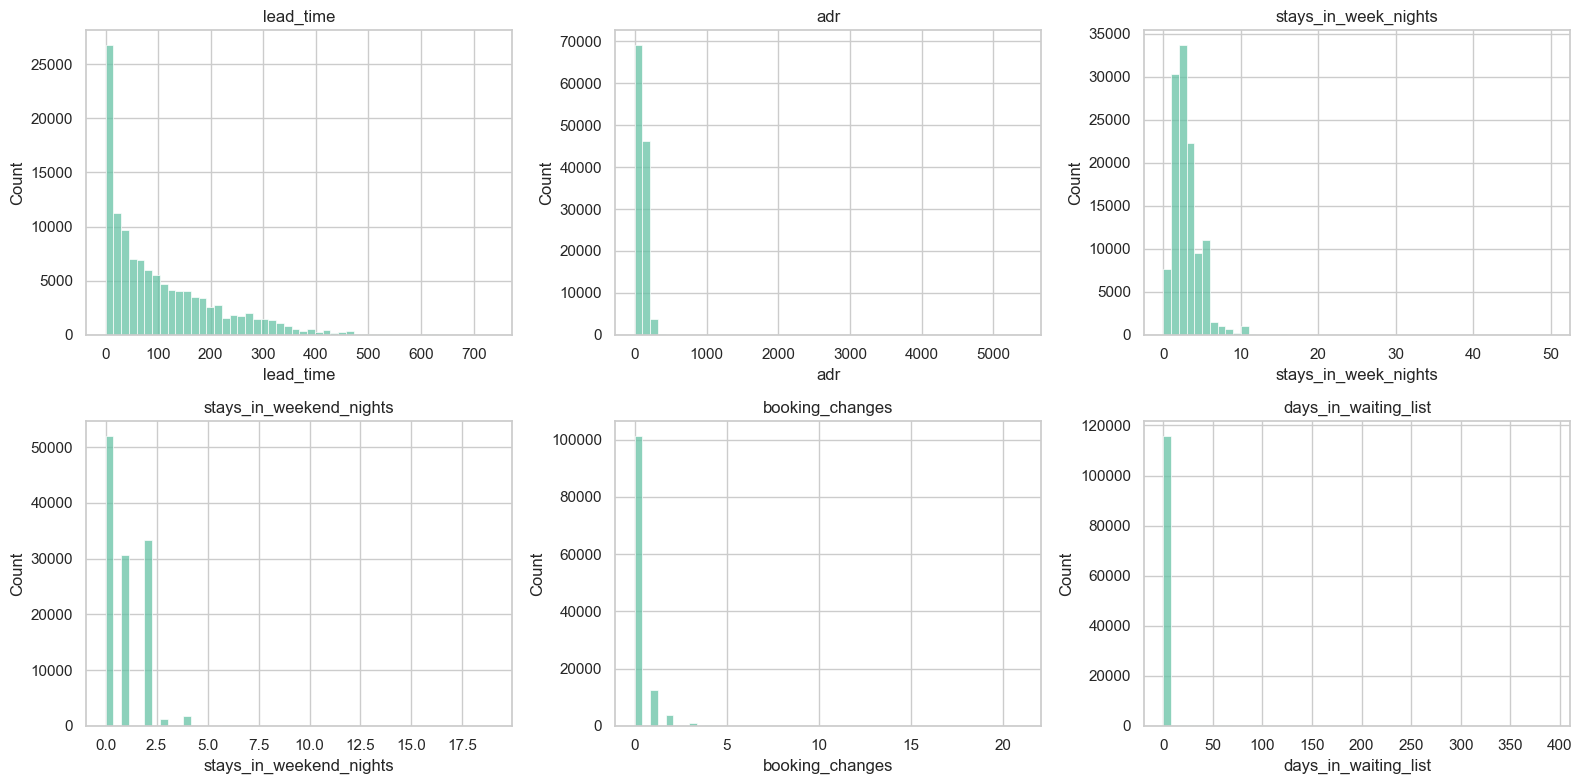

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
plot_cols = ["lead_time", "adr", "stays_in_week_nights", "stays_in_weekend_nights", "booking_changes", "days_in_waiting_list"]
for ax, col in zip(axes.ravel(), plot_cols):
    sns.histplot(df[col].dropna(), bins=50, kde=False, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

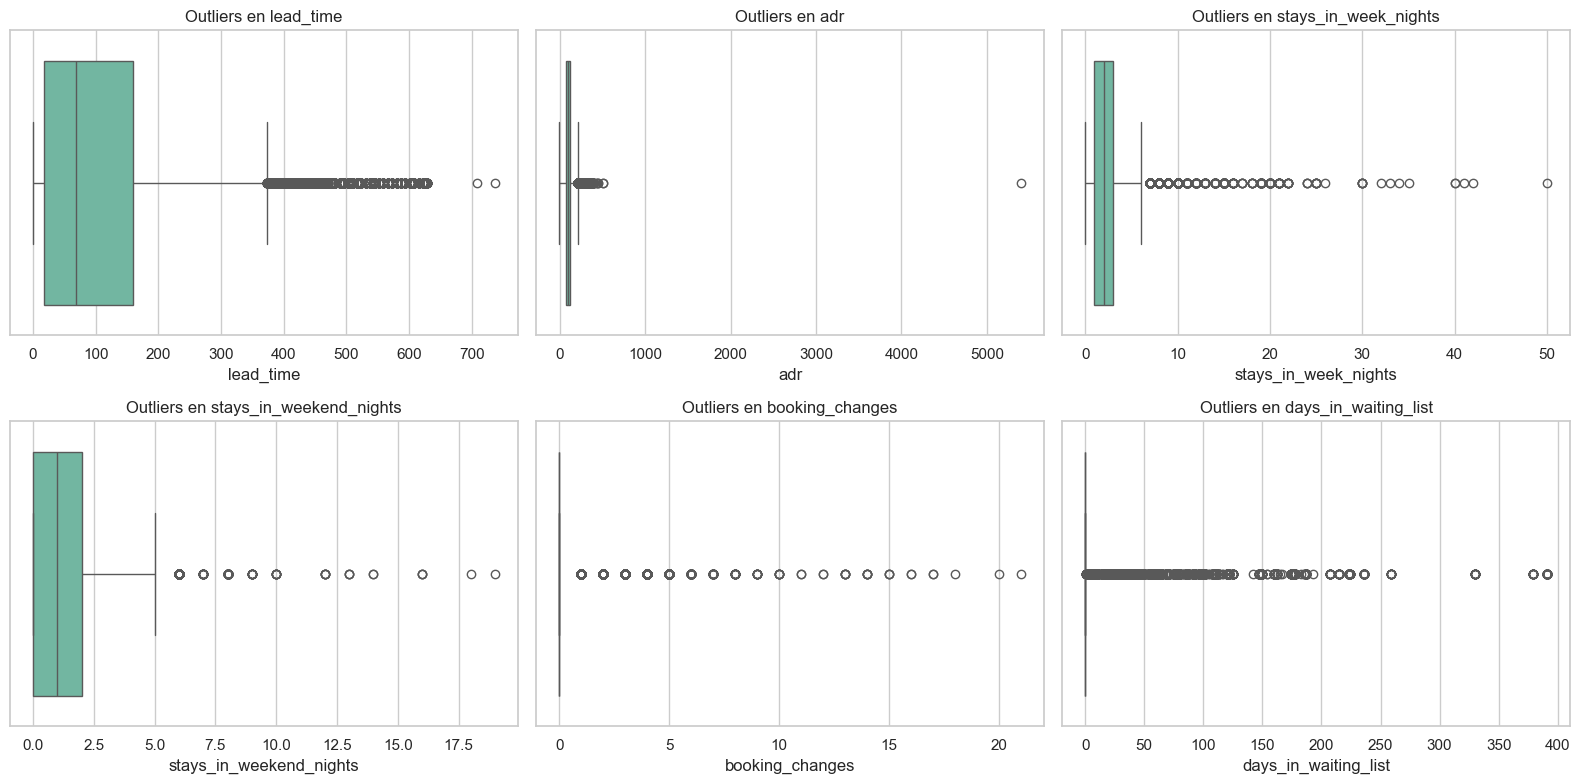

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), plot_cols):
    sns.boxplot(data=df, x=col, ax=ax)
    ax.set_title(f"Outliers en {col}")
plt.tight_layout()
plt.show()

### Casos anomalos o a revisar

In [16]:
quality_checks = pd.DataFrame({
    "caso": [
        "reservas_sin_huespedes",
        "reservas_sin_noches",
        "adr_negativo",
        "adr_igual_0",
        "adr_mayor_1000",
        "adults_igual_0",
        "adults_mayor_10",
        "children_mayor_5",
        "babies_mayor_5",
    ],
    "conteo": [
        ((df["adults"] + df["children"].fillna(0) + df["babies"]) == 0).sum(),
        ((df["stays_in_weekend_nights"] + df["stays_in_week_nights"]) == 0).sum(),
        (df["adr"] < 0).sum(),
        (df["adr"] == 0).sum(),
        (df["adr"] > 1000).sum(),
        (df["adults"] == 0).sum(),
        (df["adults"] > 10).sum(),
        (df["children"].fillna(0) > 5).sum(),
        (df["babies"] > 5).sum(),
    ],
})
quality_checks

,caso,conteo
0,reservas_sin_huespedes,180
1,reservas_sin_noches,715
2,adr_negativo,1
3,adr_igual_0,1959
4,adr_mayor_1000,1
5,adults_igual_0,403
6,adults_mayor_10,12
7,children_mayor_5,1
8,babies_mayor_5,2


**Decisiones iniciales de calidad:**

- Revisar reservas sin huespedes y sin noches. Para modelado pueden eliminarse si no representan una reserva real.
- `adr` negativo es anomalía clara; se debe eliminar.
- `adr` muy alto debe revisarse como outlier.
- Valores extremos en `adults`, `children` o `babies` se revisaran antes de entrenar.

## 8. Analisis de variables categoricas

Reviso cardinalidad, categorias principales y categorias raras. Esto ayuda a decidir One-Hot Encoding, agrupaciones o eliminacion.

In [17]:
categorical_columns = df.select_dtypes(exclude=["number"]).columns.tolist()
cat_summary = pd.DataFrame({
    "variable": categorical_columns,
    "valores_unicos": [df[col].nunique(dropna=False) for col in categorical_columns],
})
cat_summary.sort_values("valores_unicos", ascending=False)

,variable,valores_unicos
11,reservation_status_date,926
3,country,178
7,assigned_room_type,12
1,arrival_date_month,12
6,reserved_room_type,10
4,market_segment,8
5,distribution_channel,5
2,meal,5
9,customer_type,4
8,deposit_type,3


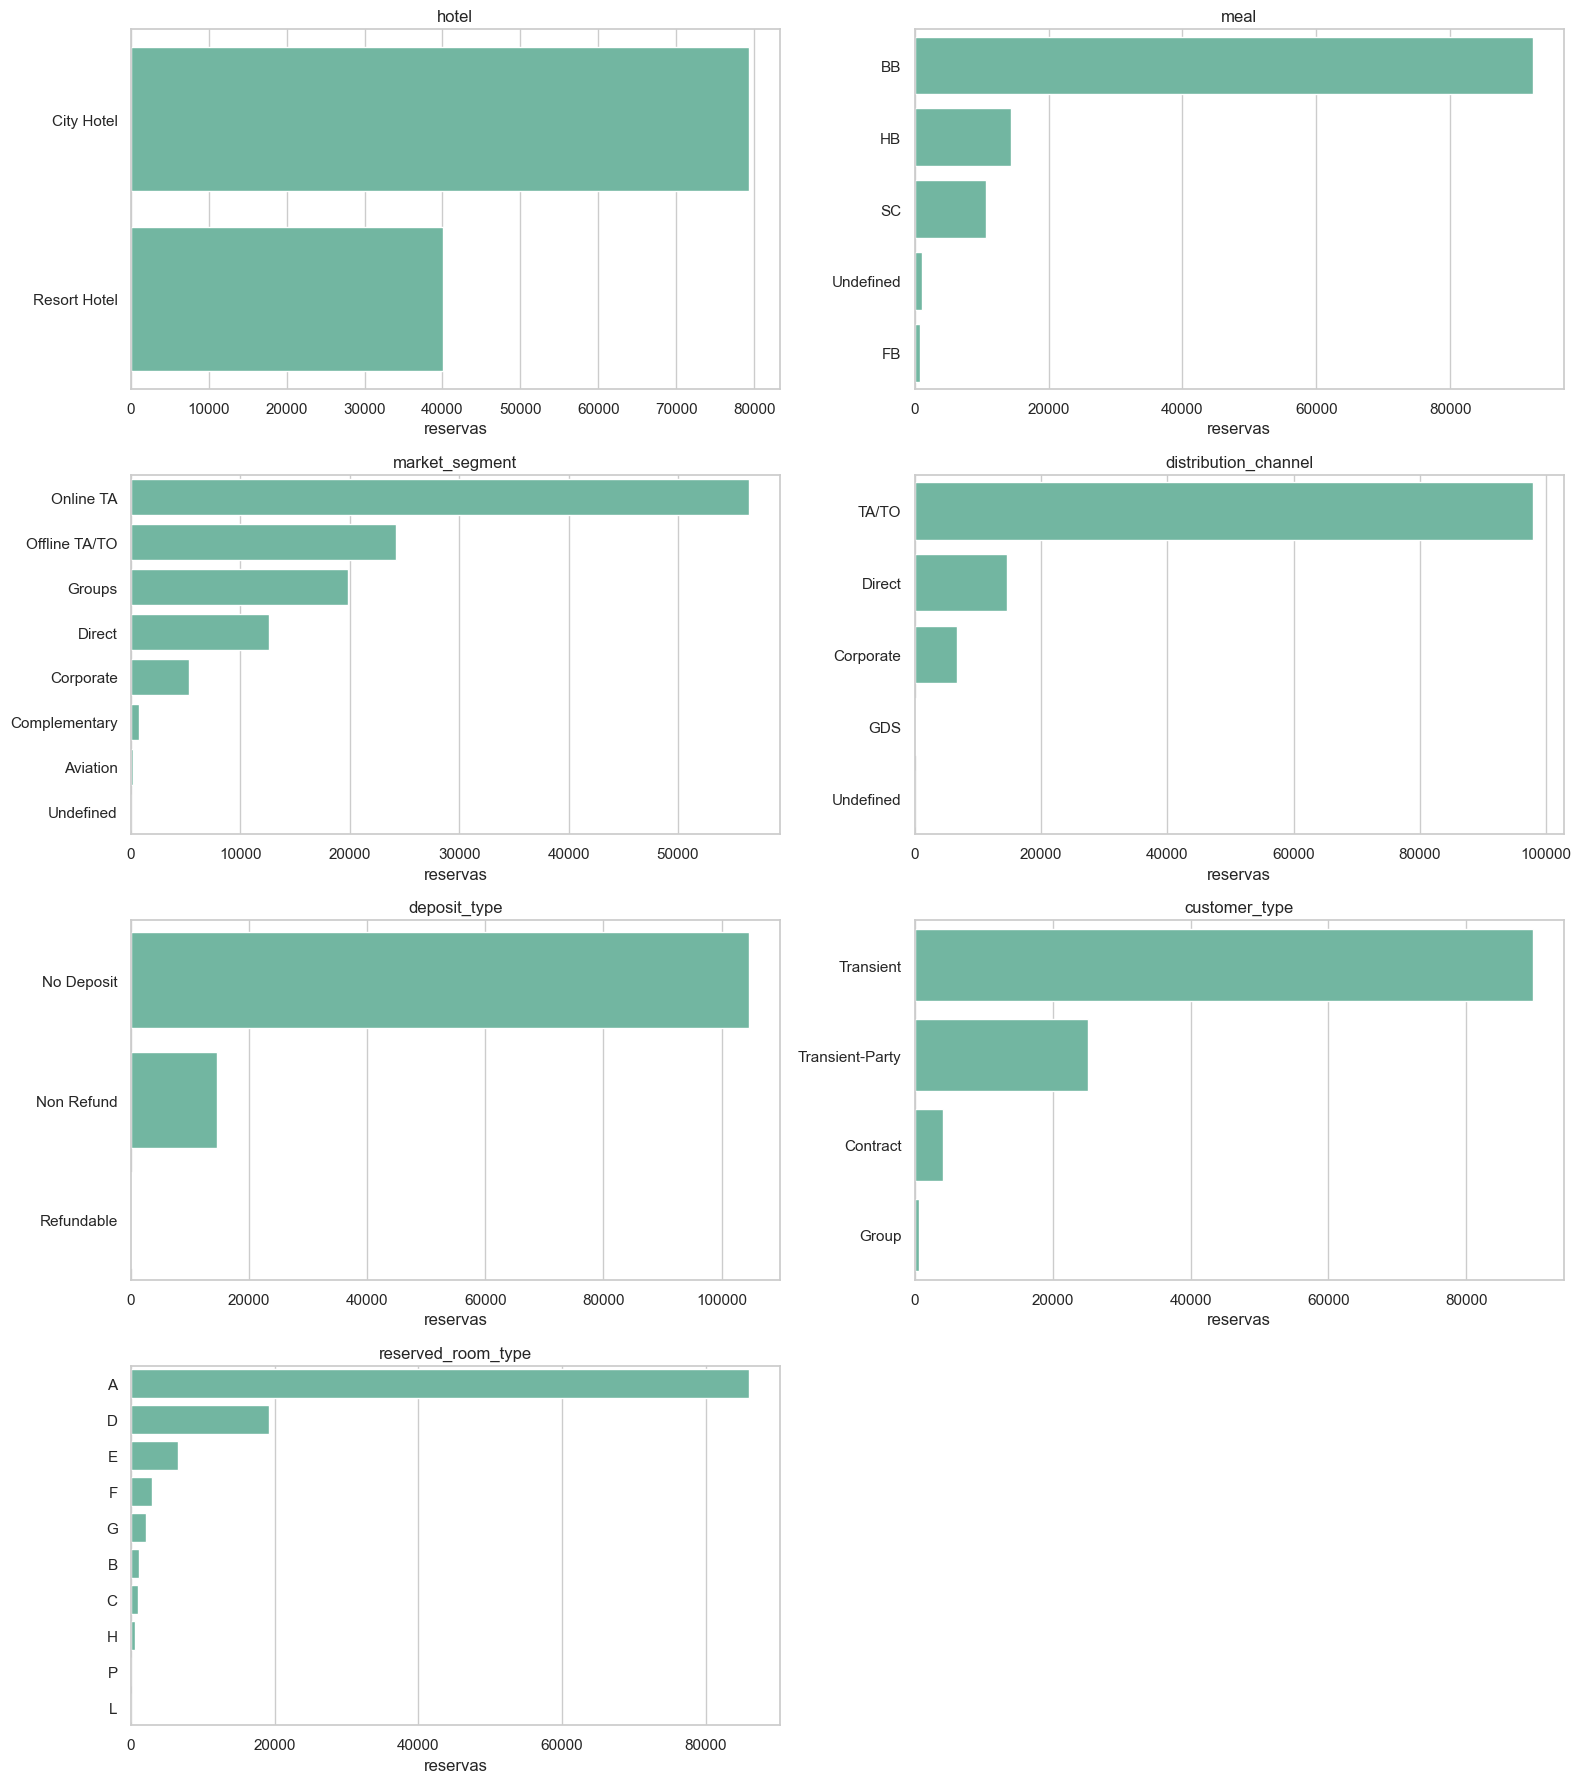

In [18]:
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
plot_cat_cols = ["hotel", "meal", "market_segment", "distribution_channel", "deposit_type", "customer_type","reserved_room_type"]
for ax, col in zip(axes.ravel(), plot_cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("reservas")
    ax.set_ylabel("")

# Ocultar el subplot vacío
axes.ravel()[-1].set_visible(False)

plt.tight_layout()
plt.show()

### Paises

`country` tiene alta cardinalidad. Conviene imputar nulos con `Unknown` y, si el One-Hot genera demasiadas columnas, agrupar paises poco frecuentes en `Other`.

In [19]:
country_counts = df["country"].value_counts(dropna=False).head(10)

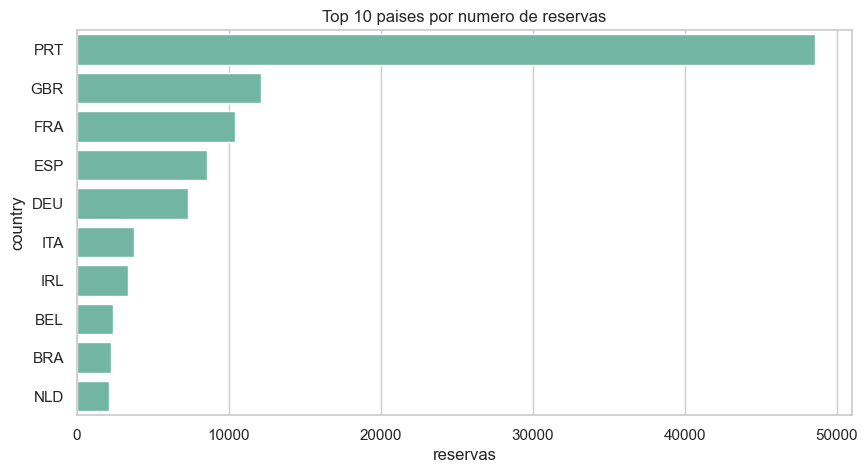

In [20]:
ax = sns.barplot(x=country_counts.values, y=country_counts.index.astype(str))
ax.set_title("Top 10 paises por numero de reservas")
ax.set_xlabel("reservas")
ax.set_ylabel("country")
plt.show()

## 9. Relacion de variables con la cancelacion

Analizo las variables principales contra `is_canceled` para entender patrones antes de modelar. Esto no implica causalidad, pero ayuda a crear hipotesis y preparar features.

In [21]:
def cancellation_rate_table(data, column, min_count=0):
    table = (
        data.groupby(column, dropna=False)[TARGET]
        .agg(reservas="count", tasa_cancelacion="mean")
        .reset_index()
    )
    table["tasa_cancelacion"] = (table["tasa_cancelacion"] * 100).round(2)
    table = table[table["reservas"] >= min_count]
    return table.sort_values("tasa_cancelacion", ascending=False)

def plot_cancellation_rate(data, column, min_count=0, top=None):
    table = cancellation_rate_table(data, column, min_count=min_count)
    if top:
        table = table.head(top)
    ax = sns.barplot(data=table, x="tasa_cancelacion", y=column)
    ax.set_title(f"Tasa de cancelacion por {column}")
    ax.set_xlabel("Cancelaciones (%)")
    ax.set_ylabel(column)
    plt.show()
    return table

### Tipo de hotel

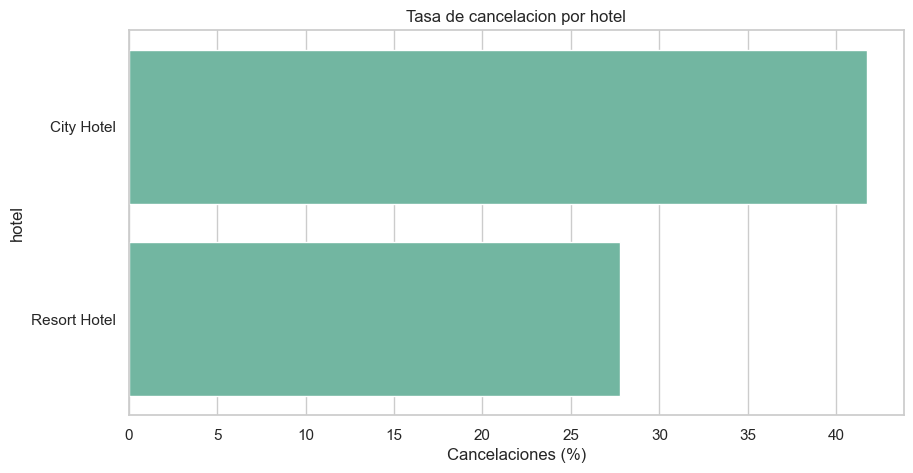

,hotel,reservas,tasa_cancelacion
0,City Hotel,79330,41.73
1,Resort Hotel,40060,27.76


In [22]:
plot_cancellation_rate(df, "hotel")

### Antelacion de la reserva (`lead_time`)

,lead_time_range,reservas,tasa_cancelacion
5,>365,3148,67.66
4,181-365,21544,55.45
3,91-180,26439,44.71
2,31-90,29553,37.70
1,8-30,18960,27.86
0,0-7,19746,9.63


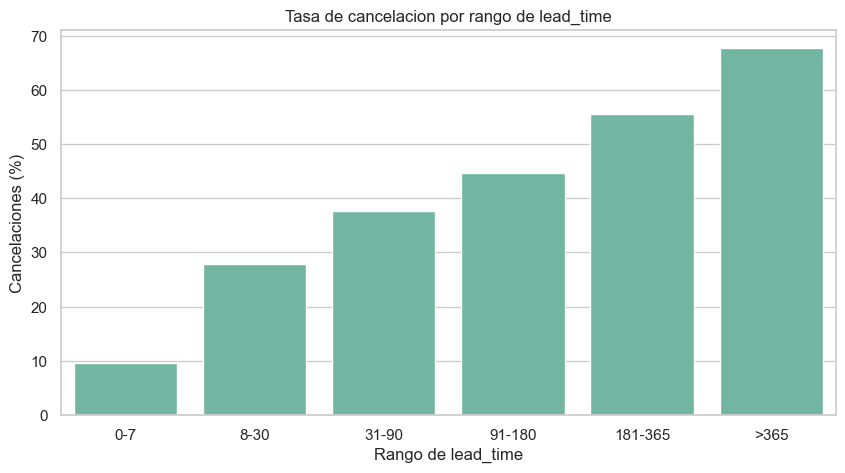

In [23]:
df_lead = df.copy()
df_lead["lead_time_range"] = pd.cut(
    df_lead["lead_time"],
    bins=[-1, 7, 30, 90, 180, 365, np.inf],
    labels=["0-7", "8-30", "31-90", "91-180", "181-365", ">365"],
)
lead_table = cancellation_rate_table(df_lead, "lead_time_range")
display(lead_table)

ax = sns.barplot(data=lead_table, x="lead_time_range", y="tasa_cancelacion")
ax.set_title("Tasa de cancelacion por rango de lead_time")
ax.set_xlabel("Rango de lead_time")
ax.set_ylabel("Cancelaciones (%)")
plt.show()

### Tipo de deposito

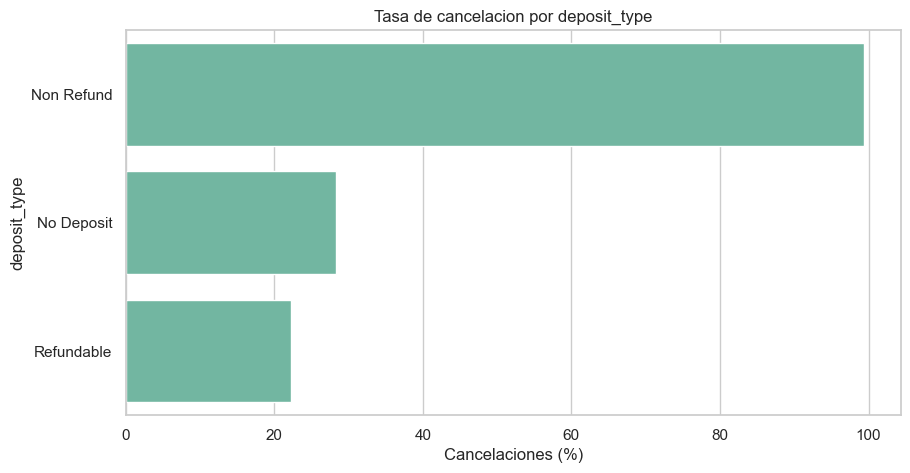

,deposit_type,reservas,tasa_cancelacion
1,Non Refund,14587,99.36
0,No Deposit,104641,28.38
2,Refundable,162,22.22


In [24]:
plot_cancellation_rate(df, "deposit_type")

### Segmento de mercado y canal de distribucion

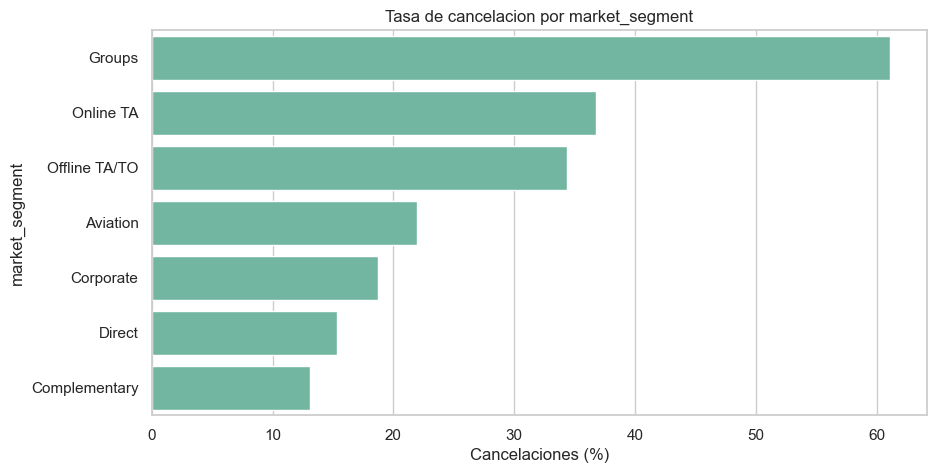

,market_segment,reservas,tasa_cancelacion
4,Groups,19811,61.06
6,Online TA,56477,36.72
5,Offline TA/TO,24219,34.32
0,Aviation,237,21.94
2,Corporate,5295,18.73
3,Direct,12606,15.34
1,Complementary,743,13.06


In [25]:
plot_cancellation_rate(df[df["market_segment"] != "Undefined"], "market_segment")

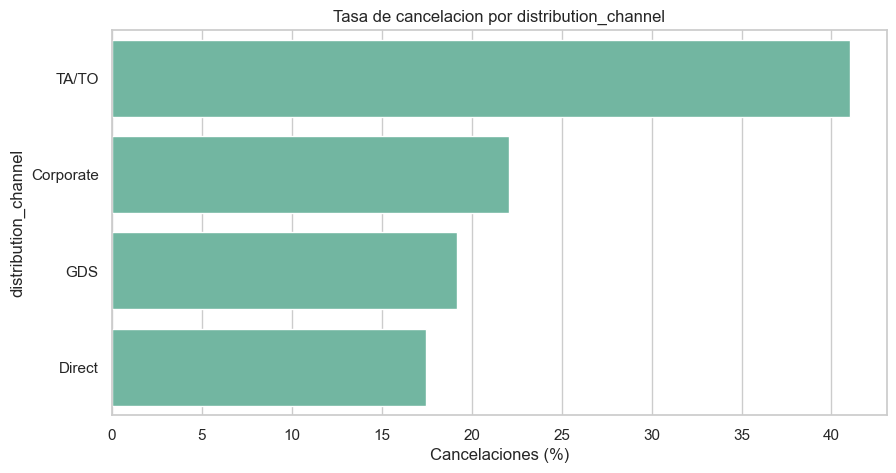

,distribution_channel,reservas,tasa_cancelacion
3,TA/TO,97870,41.03
0,Corporate,6677,22.08
2,GDS,193,19.17
1,Direct,14645,17.46


In [26]:
plot_cancellation_rate(df[df["distribution_channel"] != "Undefined"], "distribution_channel")

### Tipo de cliente

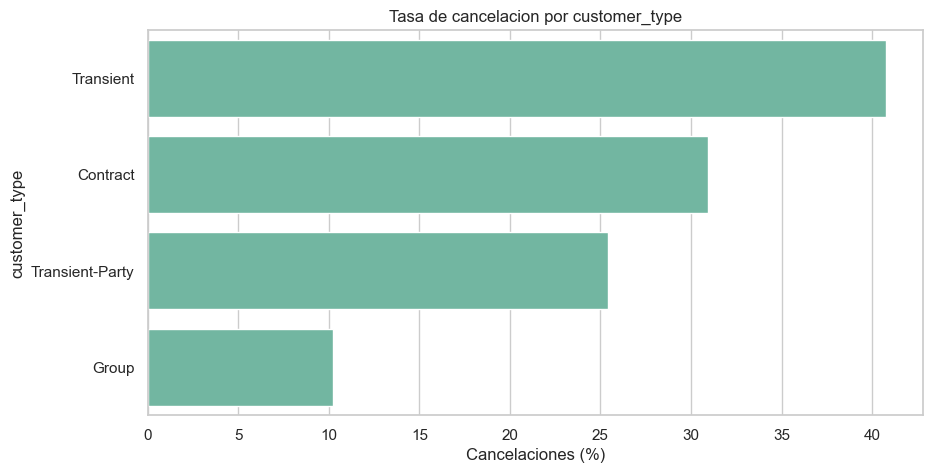

,customer_type,reservas,tasa_cancelacion
2,Transient,89613,40.75
0,Contract,4076,30.96
3,Transient-Party,25124,25.43
1,Group,577,10.23


In [27]:
plot_cancellation_rate(df, "customer_type")

### Peticiones especiales y parking

In [28]:
def plot_cancellation_rate_ordered(data, column, min_count=0):
    table = cancellation_rate_table(data, column, min_count=min_count)
    table = table.sort_values(column)

    ax = sns.barplot(data=table, x=column, y="tasa_cancelacion")
    ax.set_title(f"Tasa de cancelacion por {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Cancelaciones (%)")
    plt.show()

    return table

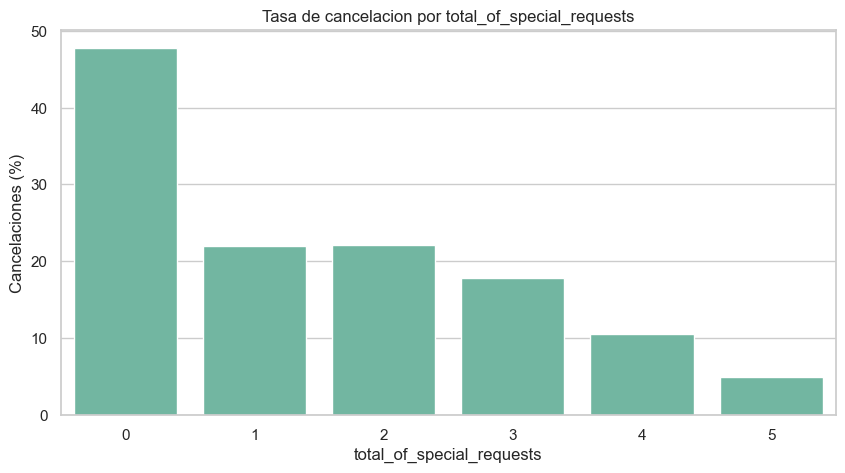

,total_of_special_requests,reservas,tasa_cancelacion
0,0,70318,47.72
1,1,33226,22.02
2,2,12969,22.10
3,3,2497,17.86
4,4,340,10.59
5,5,40,5.00


In [29]:
plot_cancellation_rate_ordered(df, "total_of_special_requests")

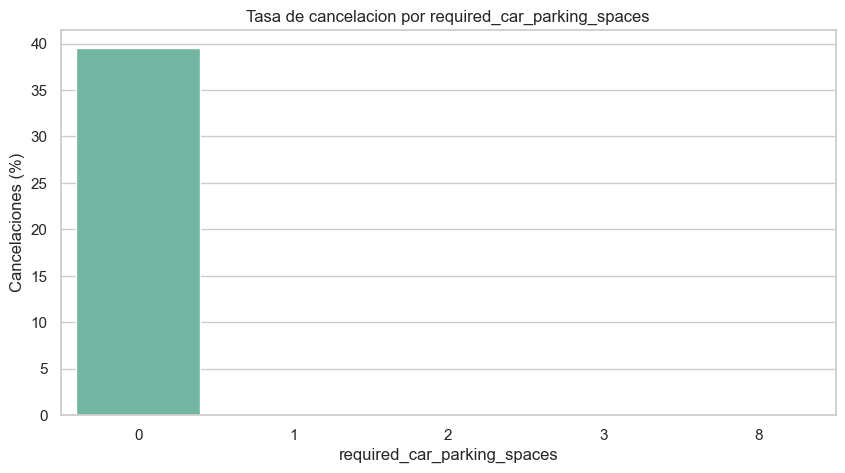

,required_car_parking_spaces,reservas,tasa_cancelacion
0,0,111974,39.49
1,1,7383,0.00
2,2,28,0.00
3,3,3,0.00
4,8,2,0.00


In [30]:
plot_cancellation_rate_ordered(df, "required_car_parking_spaces")

### Historial del cliente

In [31]:
history_cols = ["is_repeated_guest", "previous_cancellations", "previous_bookings_not_canceled"]
df[history_cols + [TARGET]].groupby(TARGET).mean().round(3)

,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled
is_canceled,,,
0,0.043,0.016,0.203
1,0.012,0.208,0.025


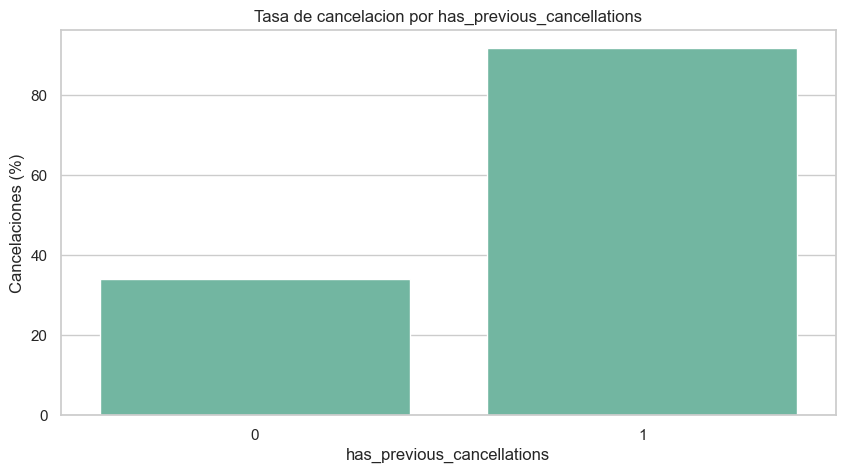

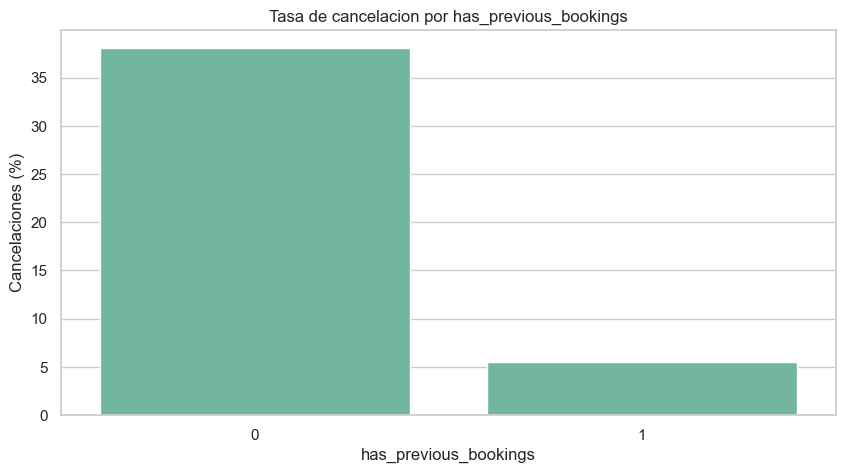

,has_previous_bookings,reservas,tasa_cancelacion
0,0,115770,38.03
1,1,3620,5.52


In [32]:
df_history = df.copy()
df_history["has_previous_cancellations"] = (df_history["previous_cancellations"] > 0).astype(int)
df_history["has_previous_bookings"] = (df_history["previous_bookings_not_canceled"] > 0).astype(int)
plot_cancellation_rate_ordered(df_history, "has_previous_cancellations")
plot_cancellation_rate_ordered(df_history, "has_previous_bookings")

### Precio medio diario (`adr`)

,adr_range,reservas,tasa_cancelacion
2,"(85.0, 105.0]",23278,39.31
3,"(105.0, 135.0]",24390,39.16
4,"(135.0, 252.0]",23334,37.65
0,"(-0.001, 64.0]",23912,34.97
1,"(64.0, 85.0]",24476,34.22


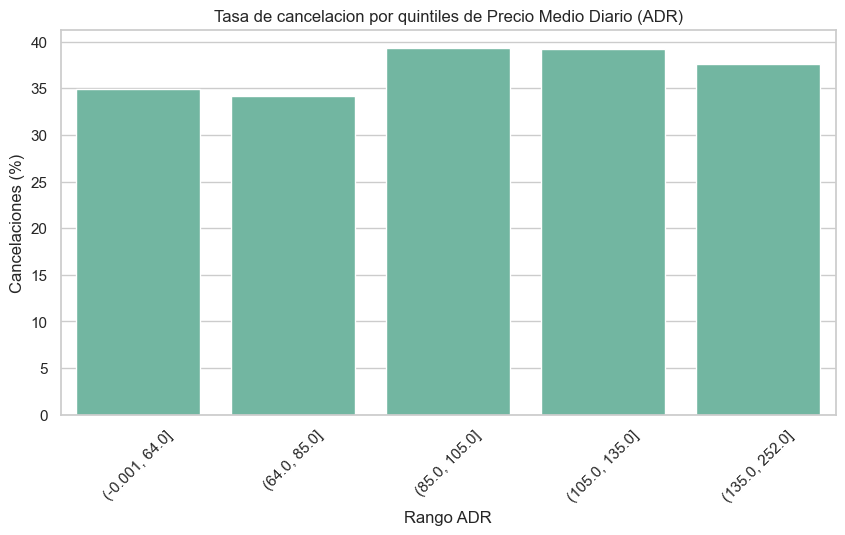

In [33]:
df_adr = df.copy()
df_adr["adr_clipped"] = df_adr["adr"].clip(lower=0, upper=df_adr["adr"].quantile(0.99))
df_adr["adr_range"] = pd.qcut(df_adr["adr_clipped"], q=5, duplicates="drop")
adr_table = cancellation_rate_table(df_adr, "adr_range")
display(adr_table)

ax = sns.barplot(data=adr_table, x="adr_range", y="tasa_cancelacion")
ax.set_title("Tasa de cancelacion por quintiles de Precio Medio Diario (ADR)")
ax.set_xlabel("Rango ADR")
ax.set_ylabel("Cancelaciones (%)")
plt.xticks(rotation=45)
plt.show()

### Temporalidad: mes de llegada

,arrival_date_month,reservas,tasa_cancelacion
4,January,5929,30.48
3,February,8068,33.42
7,March,9794,32.15
0,April,11089,40.80
8,May,11791,39.67
6,June,10939,41.46
5,July,12661,37.45
1,August,13877,37.75
11,September,10508,39.17
10,October,11160,38.05


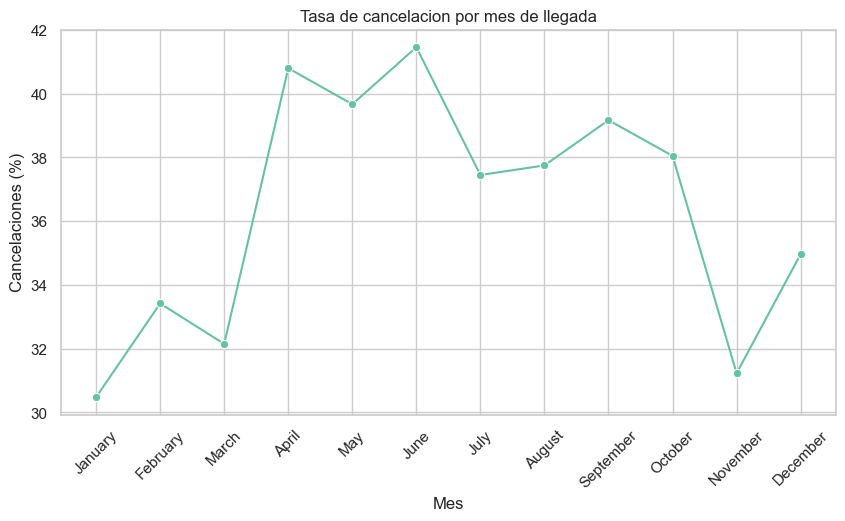

In [34]:
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
month_table = cancellation_rate_table(df, "arrival_date_month")
month_table["arrival_date_month"] = pd.Categorical(month_table["arrival_date_month"], categories=month_order, ordered=True)
month_table = month_table.sort_values("arrival_date_month")
display(month_table)

ax = sns.lineplot(data=month_table, x="arrival_date_month", y="tasa_cancelacion", marker="o")
ax.set_title("Tasa de cancelacion por mes de llegada")
ax.set_xlabel("Mes")
ax.set_ylabel("Cancelaciones (%)")
plt.xticks(rotation=45)
plt.show()

### Analisis temporal con fecha de llegada y fecha estimada de reserva

A partir de `arrival_date_year`, `arrival_date_month` y `arrival_date_day_of_month` se construye una fecha de llegada. El dataset no trae directamente la fecha exacta en la que se hizo la reserva, pero se puede estimar restando `lead_time` a la fecha de llegada. Esto permite analizar evolucion temporal sin convertir el proyecto en un modelo de series temporales.


In [35]:
df_time = df.copy()

month_to_number = {month: number for number, month in enumerate(month_order, start=1)}
df_time["arrival_month_number"] = df_time["arrival_date_month"].map(month_to_number)

df_time["arrival_date"] = pd.to_datetime(
    dict(
        year=df_time["arrival_date_year"],
        month=df_time["arrival_month_number"],
        day=df_time["arrival_date_day_of_month"],
    ),
    errors="coerce",
)

df_time["booking_date_estimated"] = df_time["arrival_date"] - pd.to_timedelta(df_time["lead_time"], unit="D")

print(f"Fechas de llegada no validas: {df_time["arrival_date"].isna().sum():,}".replace(",", "."))
display(df_time[["arrival_date", "booking_date_estimated", "lead_time"]].head())    


Fechas de llegada no validas: 0


,arrival_date,booking_date_estimated,lead_time
0,2015-07-01,2014-07-24,342
1,2015-07-01,2013-06-24,737
2,2015-07-01,2015-06-24,7
3,2015-07-01,2015-06-18,13
4,2015-07-01,2015-06-17,14


,arrival_date,reservas,cancelaciones,tasa_cancelacion
0,2015-07-01,2776,1259,45.35
1,2015-08-01,3889,1598,41.09
2,2015-09-01,5114,2094,40.95
3,2015-10-01,4957,1732,34.94
4,2015-11-01,2340,486,20.77
5,2015-12-01,2920,973,33.32
6,2016-01-01,2248,557,24.78
7,2016-02-01,3891,1337,34.36
8,2016-03-01,4824,1477,30.62
9,2016-04-01,5428,2061,37.97


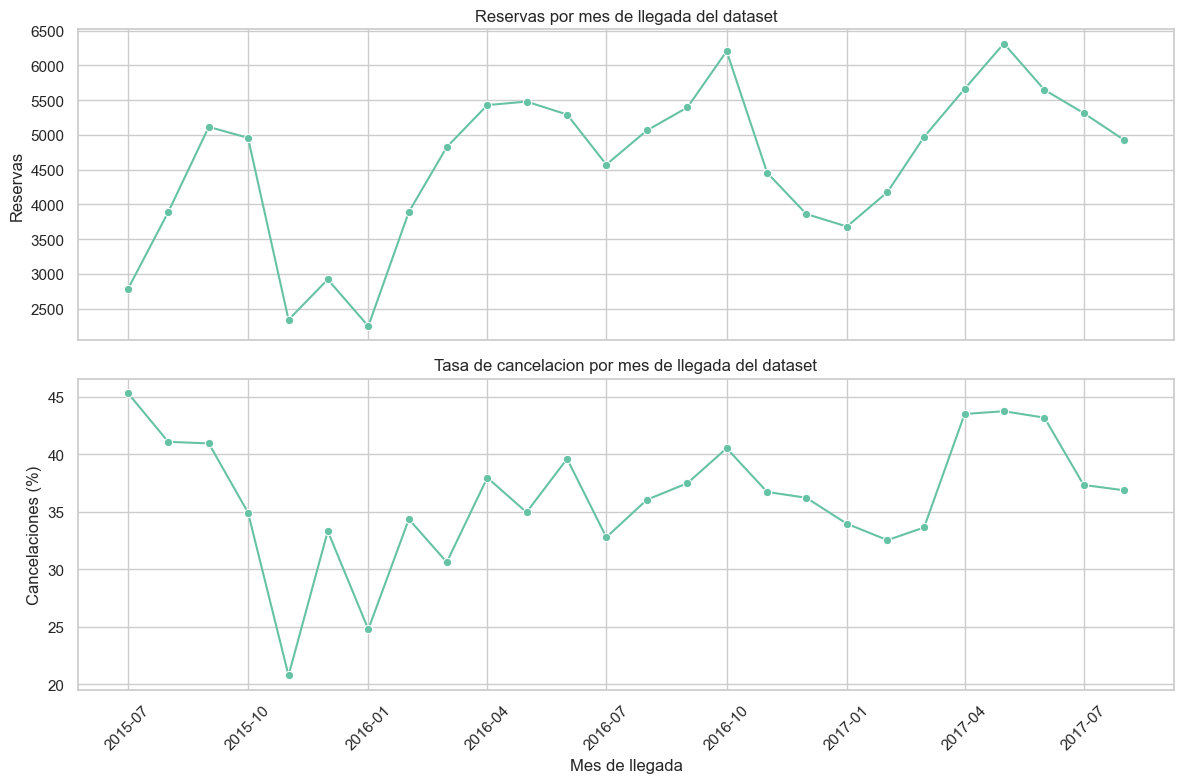

In [36]:
arrival_monthly_table = (
    df_time.dropna(subset=["arrival_date"])
    .set_index("arrival_date")
    .resample("MS")[TARGET]
    .agg(reservas="count", cancelaciones="sum", tasa_cancelacion="mean")
    .reset_index()
)
arrival_monthly_table["tasa_cancelacion"] = (arrival_monthly_table["tasa_cancelacion"] * 100).round(2)

display(arrival_monthly_table)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

sns.lineplot(data=arrival_monthly_table, x="arrival_date", y="reservas", marker="o", ax=axes[0])
axes[0].set_title("Reservas por mes de llegada del dataset")
axes[0].set_xlabel("")
axes[0].set_ylabel("Reservas")

sns.lineplot(data=arrival_monthly_table, x="arrival_date", y="tasa_cancelacion", marker="o", ax=axes[1])
axes[1].set_title("Tasa de cancelacion por mes de llegada del dataset")
axes[1].set_xlabel("Mes de llegada")
axes[1].set_ylabel("Cancelaciones (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


,booking_date_estimated,reservas,cancelaciones,tasa_cancelacion
0,2013-06-01,1,0,0.00
1,2013-07-01,0,0,NaN
2,2013-08-01,0,0,NaN
3,2013-09-01,0,0,NaN
4,2013-10-01,0,0,NaN
5,2013-11-01,0,0,NaN
6,2013-12-01,0,0,NaN
7,2014-01-01,0,0,NaN
8,2014-02-01,0,0,NaN
9,2014-03-01,1,0,0.00


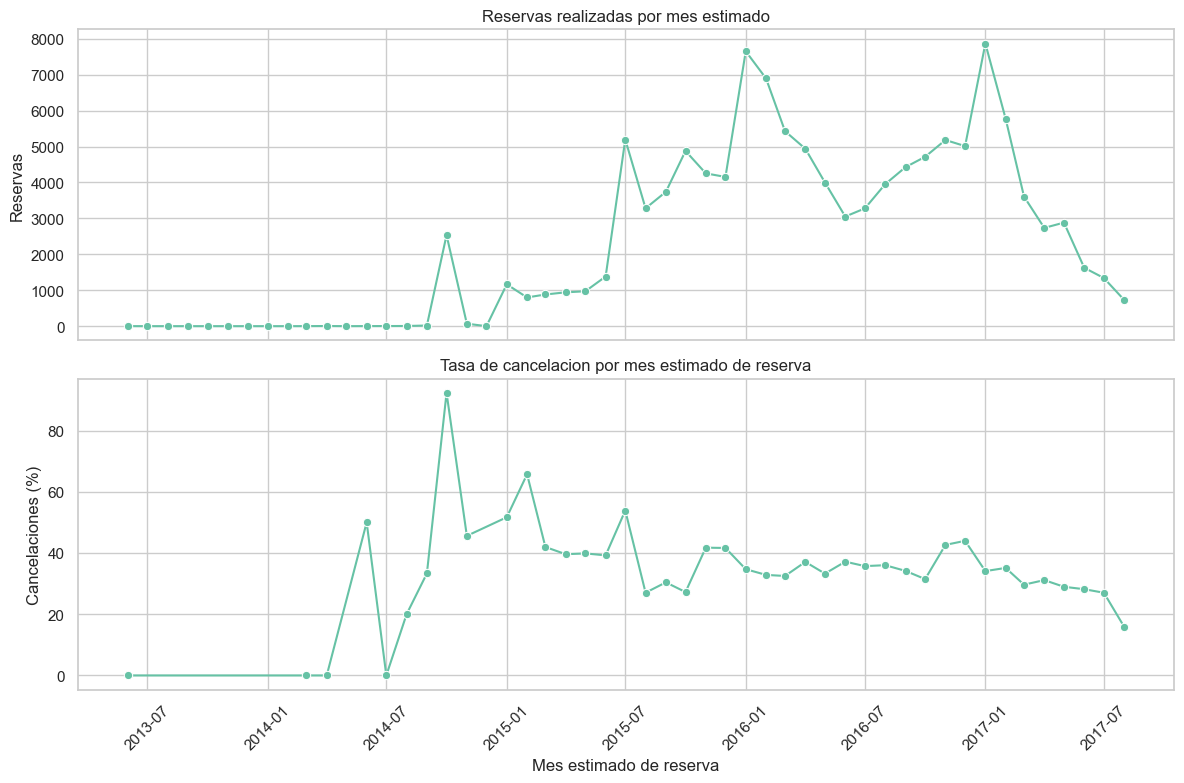

In [37]:
booking_monthly_table = (
    df_time.dropna(subset=["booking_date_estimated"])
    .set_index("booking_date_estimated")
    .resample("MS")[TARGET]
    .agg(reservas="count", cancelaciones="sum", tasa_cancelacion="mean")
    .reset_index()
)
booking_monthly_table["tasa_cancelacion"] = (booking_monthly_table["tasa_cancelacion"] * 100).round(2)

display(booking_monthly_table)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

sns.lineplot(data=booking_monthly_table, x="booking_date_estimated", y="reservas", marker="o", ax=axes[0])
axes[0].set_title("Reservas realizadas por mes estimado")
axes[0].set_xlabel("")
axes[0].set_ylabel("Reservas")

sns.lineplot(data=booking_monthly_table, x="booking_date_estimated", y="tasa_cancelacion", marker="o", ax=axes[1])
axes[1].set_title("Tasa de cancelacion por mes estimado de reserva")
axes[1].set_xlabel("Mes estimado de reserva")
axes[1].set_ylabel("Cancelaciones (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Paises con mayor volumen

,country,reservas,tasa_cancelacion
12,PRT,48590,56.64
2,BRA,2224,37.32
10,ITA,3766,35.40
6,ESP,8568,25.41
3,CHE,1730,24.74
9,IRL,3375,24.65
14,USA,2097,23.89
13,SWE,1024,22.17
1,BEL,2342,20.24
8,GBR,12129,20.22


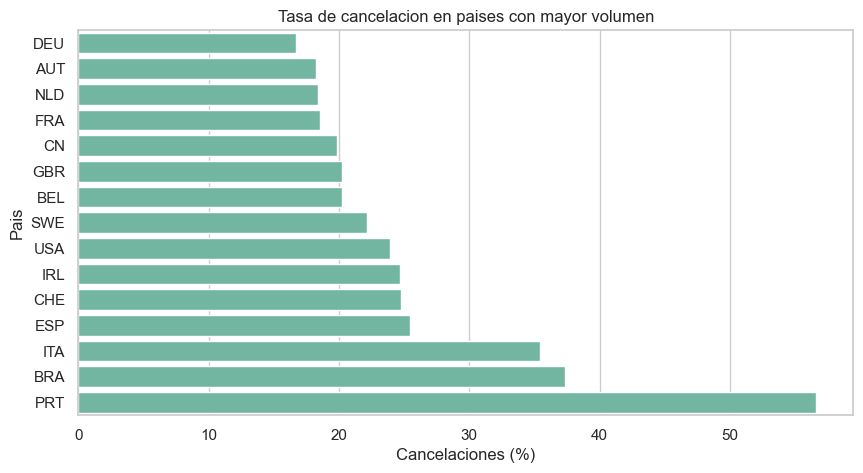

In [38]:
top_countries = df["country"].value_counts().head(15).index
country_cancel = cancellation_rate_table(df[df["country"].isin(top_countries)], "country")
display(country_cancel)

ax = sns.barplot(data=country_cancel.sort_values("tasa_cancelacion", ascending=True), x="tasa_cancelacion", y="country")
ax.set_title("Tasa de cancelacion en paises con mayor volumen")
ax.set_xlabel("Cancelaciones (%)")
ax.set_ylabel("Pais")
plt.show()

## 10. Feature engineering propuesto

A partir del analisis anterior, creo variables simples y defendibles para el primer modelado:

- `total_nights`: total de noches.
- `total_guests`: total de huespedes.
- `has_company`: si la reserva tiene empresa asociada.
- `has_agent`: si la reserva tiene agente asociado.
- `has_special_requests`: si el cliente hizo alguna peticion especial.
- `needs_parking`: si el cliente pidio parking.
- `has_previous_cancellations`: si el cliente habia cancelado antes.
- `has_previous_bookings`: si el cliente tenia reservas previas no canceladas.

Se eliminan columnas con fuga de informacion, variables a revisar y variables temporales redundantes en una primera iteracion. Los duplicados exactos se mantienen inicialmente porque no existe un identificador unico que permita confirmar que son errores.


In [39]:
df_clean = df.copy()

# 1. Mantener duplicados exactos en la primera iteracion.
# No hay booking_id, por lo que no podemos confirmar que sean errores.

# 2. Imputaciones sencillas.
df_clean["children"] = df_clean["children"].fillna(0)
df_clean["country"] = df_clean["country"].fillna("Unknown")

# 3. Variables binarias a partir de columnas con nulos o conteos.
df_clean["has_company"] = df_clean["company"].notna().astype(int)
df_clean["has_agent"] = df_clean["agent"].notna().astype(int)
df_clean["has_special_requests"] = (df_clean["total_of_special_requests"] > 0).astype(int)
df_clean["needs_parking"] = (df_clean["required_car_parking_spaces"] > 0).astype(int)
df_clean["has_previous_cancellations"] = (df_clean["previous_cancellations"] > 0).astype(int)
df_clean["has_previous_bookings"] = (df_clean["previous_bookings_not_canceled"] > 0).astype(int)

# 4. Variables agregadas.
df_clean["total_nights"] = df_clean["stays_in_weekend_nights"] + df_clean["stays_in_week_nights"]
df_clean["total_guests"] = df_clean["adults"] + df_clean["children"] + df_clean["babies"]

# 5. Eliminar registros anomalos claros para una primera iteracion.
df_clean = df_clean[df_clean["total_guests"] > 0]
df_clean = df_clean[df_clean["total_nights"] > 0]
df_clean = df_clean[df_clean["adr"] >= 0]

# 6. Eliminar columnas no utilizables en el primer modelo.
columns_to_drop = [
    "reservation_status",       # fuga de informacion
    "reservation_status_date",  # fuga de informacion
    "assigned_room_type",       # posible informacion posterior
    "arrival_date_week_number", # redundante con year/month/day
    "company",                  # muchos nulos; sustituida por has_company
    "agent",                    # identificador; sustituida por has_agent
]
df_clean = df_clean.drop(columns=columns_to_drop)

df_clean.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,has_company,has_agent,has_special_requests,needs_parking,has_previous_cancellations,has_previous_bookings,total_nights,total_guests
2,Resort Hotel,0,7,2015,July,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,0,No Deposit,0,Transient,75.0,0,0,0,0,0,0,0,0,1,1.0
3,Resort Hotel,0,13,2015,July,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,0,No Deposit,0,Transient,75.0,0,0,0,1,0,0,0,0,1,1.0
4,Resort Hotel,0,14,2015,July,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,0,No Deposit,0,Transient,98.0,0,1,0,1,1,0,0,0,2,2.0
5,Resort Hotel,0,14,2015,July,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,0,No Deposit,0,Transient,98.0,0,1,0,1,1,0,0,0,2,2.0
6,Resort Hotel,0,0,2015,July,1,0,2,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,0,No Deposit,0,Transient,107.0,0,0,0,0,0,0,0,0,2,2.0


## 11. Correlacion entre variables numericas

Una vez creadas las variables iniciales de ingenieria de datos, reviso la correlacion entre las variables numericas de `df_clean`. La correlacion no captura relaciones no lineales, pero ayuda a detectar variables redundantes y relaciones fuertes.


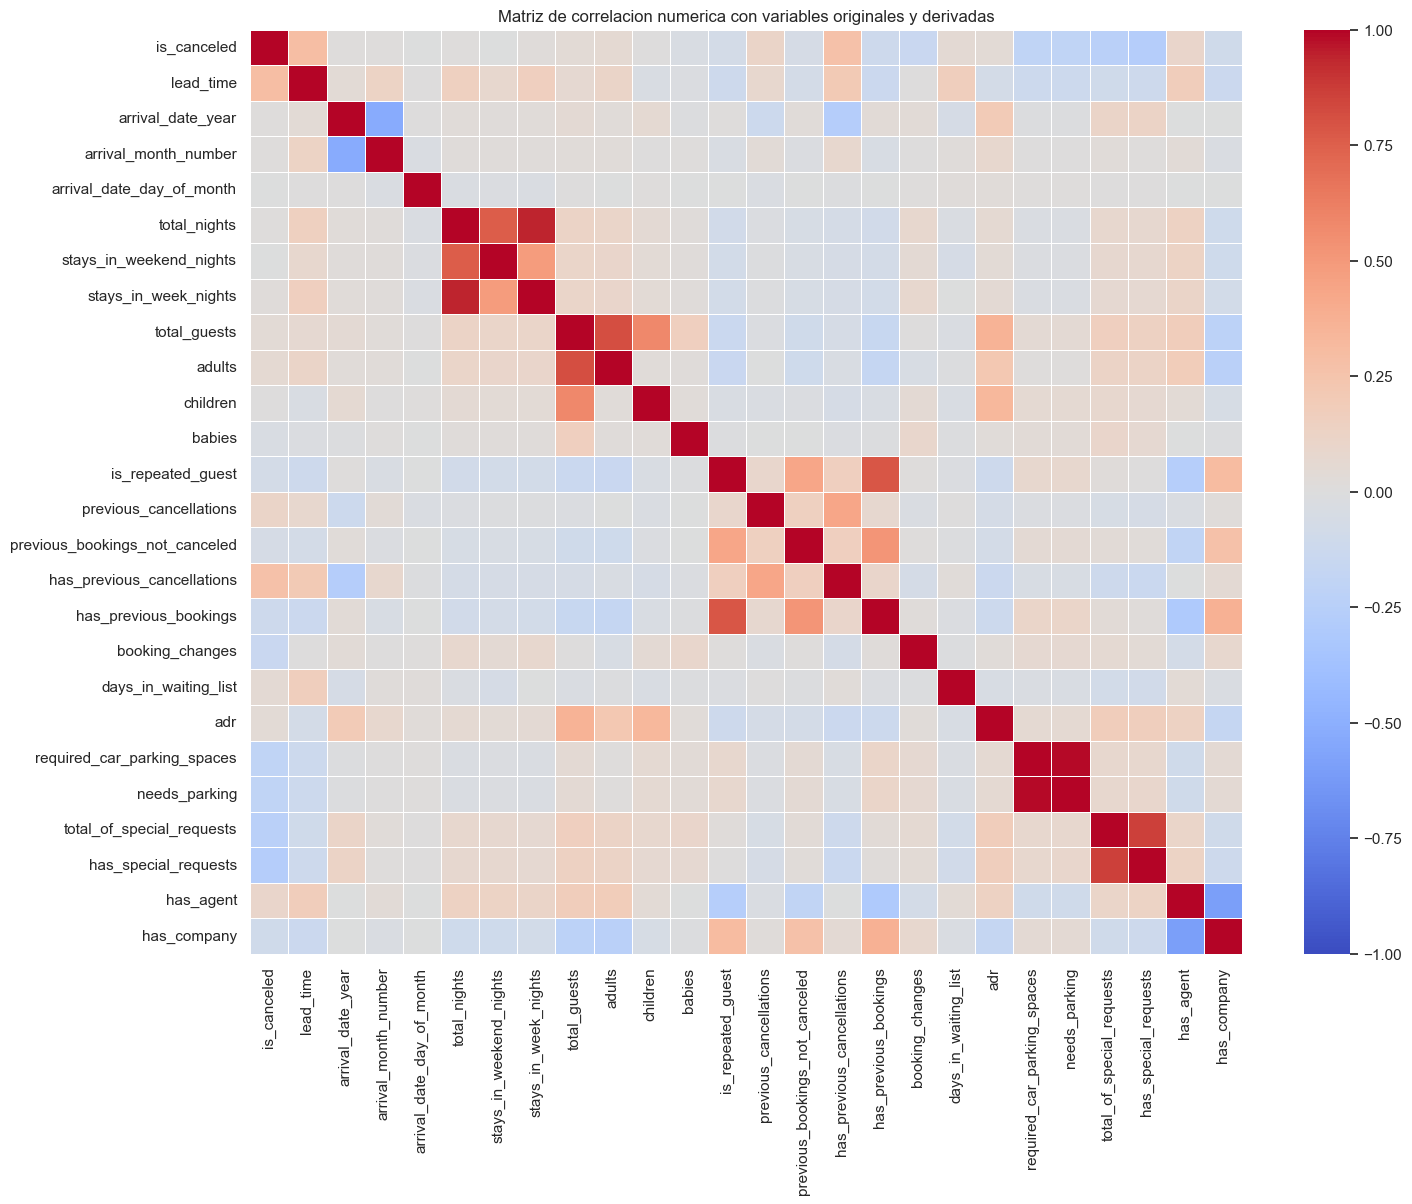

In [40]:
df_corr = df_clean.copy()

# Variable auxiliar solo para la matriz de correlacion.
month_to_number = {month: number for number, month in enumerate(month_order, start=1)}
df_corr["arrival_month_number"] = df_corr["arrival_date_month"].map(month_to_number)

corr_cols = [
    "is_canceled",
    "lead_time",
    "arrival_date_year",
    "arrival_month_number",
    "arrival_date_day_of_month",
    "total_nights",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "total_guests",
    "adults",
    "children",
    "babies",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "has_previous_cancellations",
    "has_previous_bookings",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "needs_parking",
    "total_of_special_requests",
    "has_special_requests",
    "has_agent",
    "has_company",
]

corr = df_corr[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5, vmin=-1, vmax=1)
plt.title("Matriz de correlacion numerica con variables originales y derivadas")
plt.show()


In [41]:
corr[TARGET].sort_values(ascending=False).to_frame("correlacion_con_target")

,correlacion_con_target
is_canceled,1.000000
lead_time,0.291523
has_previous_cancellations,0.270813
previous_cancellations,0.109973
has_agent,0.101081
adults,0.057576
days_in_waiting_list,0.053940
total_guests,0.044238
adr,0.039355
stays_in_week_nights,0.020716


## 12. Comprobacion del dataframe limpio

In [42]:
print(f"Filas originales: {df.shape[0]:,}".replace(",", "."))
print(f"Filas limpias: {df_clean.shape[0]:,}".replace(",", "."))
print(f"Columnas limpias: {df_clean.shape[1]}")

df_clean.isna().sum().sort_values(ascending=False).head(10)

Filas originales: 119.390
Filas limpias: 118.564
Columnas limpias: 34


hotel                        0
is_canceled                  0
lead_time                    0
arrival_date_year            0
arrival_date_month           0
arrival_date_day_of_month    0
stays_in_weekend_nights      0
stays_in_week_nights         0
adults                       0
children                     0
dtype: int64

In [43]:
pd.DataFrame({
    "variable": df_clean.columns,
    "tipo": [str(df_clean[col].dtype) for col in df_clean.columns],
    "nulos": [df_clean[col].isna().sum() for col in df_clean.columns],
    "valores_unicos": [df_clean[col].nunique(dropna=False) for col in df_clean.columns],
})

,variable,tipo,nulos,valores_unicos
0,hotel,str,0,2
1,is_canceled,int64,0,2
2,lead_time,int64,0,478
3,arrival_date_year,int64,0,3
4,arrival_date_month,str,0,12
5,arrival_date_day_of_month,int64,0,31
6,stays_in_weekend_nights,int64,0,17
7,stays_in_week_nights,int64,0,33
8,adults,int64,0,14
9,children,float64,0,5


## 13. Guardado del dataset procesado

Guardo un unico archivo procesado:

- `data/processed/hotel_bookings_clean.csv`: dataset limpio completo.

La division train/test se realiza en `03_Entrenamiento_Evaluacion.ipynb`, porque alli se comparan las versiones con duplicados y sin duplicados.


In [44]:
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)

df_clean.to_csv(PROCESSED_PATH, index=False)

print(PROCESSED_PATH)


..\data\processed\hotel_bookings_clean.csv


## 14. Conclusiones del EDA

- El dataset cumple de sobra el volumen minimo del proyecto.
- El target tiene una proporcion suficiente de reservas canceladas para entrenar modelos.
- Hay duplicados exactos; se documentan, pero no se eliminan en la primera iteracion porque cada observacion representa una reserva y no existe `booking_id` para confirmar que sean errores.
- Los nulos se concentran en `company`, `agent`, `country` y `children`.
- `reservation_status` y `reservation_status_date` son fuga de informacion y se eliminan.
- `assigned_room_type` se excluye en la primera iteracion por posible informacion posterior.
- `arrival_date_week_number` se elimina del dataset final porque es redundante con año, mes y dia de llegada.
- Variables como `lead_time`, `deposit_type`, `market_segment`, `total_of_special_requests`, `previous_cancellations` y `adr` muestran patrones relevantes para cancelacion.
- Se crean features simples de negocio: total de noches, total de huespedes, si tiene empresa, si tiene agente, si pidio parking y si hizo peticiones especiales.
- El siguiente paso es entrenar un baseline y comparar 5 modelos en `03_Entrenamiento_Evaluacion.ipynb`, donde se realizara la division train/test y la comparacion con y sin duplicados.